In [1]:
import pandas as pd
import numpy as np
import ast
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
from pyro.infer import MCMC, NUTS
import pyro.distributions.constraints as constraints
from pyro.infer.autoguide import AutoMultivariateNormal, init_to_mean, AutoNormal, AutoGuide
from pyro.infer import SVI, Trace_ELBO, Predictive
import pyro.optim as optim
from sklearn.model_selection import KFold
from sklearn.utils import shuffle
from tqdm import tqdm
from matplotlib import font_manager, rc

# Configure matplotlib for Korean text display
rc('font', family='DejaVu Sans')
plt.rcParams['axes.unicode_minus'] = False

# Check for CUDA (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
df = pd.read_csv('../Data/train_wd_hc.csv', index_col = 0)

df.reset_index(drop=True, inplace = True)
df.drop(columns = ['id'], inplace= True)

df_x = df[['transfer', 'outer', 'terminal', 'cbd', 'tfa_r', 'tfa_c',
       'tfa_w', 'univ', 'pop', 'job', 'bus', 'buld_sum', 'rest', 'green',
       'tfa_n', 'tfa_f', 'lumix']]
df_y = df[['pattern', 'max_ride', 'min_ride']]

df_x = df_x.apply(lambda col: col.fillna(col.min()), axis=0)

# Parse pattern strings to lists and denormalize
def denormalize_pattern(pattern_str, min_ride, max_ride):
    # Convert string representation to list
    pattern_list = ast.literal_eval(pattern_str)
    # Denormalize: value * (max_ride - min_ride) + min_ride
    denormalized = [val * (max_ride - min_ride) + min_ride for val in pattern_list]
    return np.array(denormalized)

# Apply to each row
df_y['ridership'] = df_y.apply(
    lambda row: denormalize_pattern(row['pattern'], row['min_ride'], row['max_ride']),
    axis=1
)

print(len(df))

226


C:\Users\id310624\AppData\Local\Temp\ipykernel_6004\2559102360.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_y['ridership'] = df_y.apply(


In [3]:
# Get English name
df_enname = pd.read_csv('../Data/서울교통공사_역명다국어표기_20241101.csv', encoding = 'cp949')
df_enname['한글'] = df_enname['한글'].apply(lambda x: x.split('(')[0])
df_enname.drop_duplicates(subset=['한글'], inplace=True)
df_enname.rename(columns={'한글':'name', '영문':'en_name'}, inplace=True)
df = df.merge(df_enname[['name', 'en_name']], on = 'name', how='left', suffixes=('', '_y'))

df.loc[df['name'] == '미아사거리', 'en_name'] = 'MiaSageori'
df.loc[df['name'] == '뚝섬유원지', 'en_name'] = 'DduksomPark'
df.loc[df['name'] == '화랑대', 'en_name'] = 'Hwarangdae'
df.loc[df['name'] == '서울', 'en_name'] = 'SeoulStation'

df = df[['name', 'en_name', 'transfer', 'outer', 'terminal', 'cbd', 'tfa_r', 'tfa_c',
       'tfa_w', 'univ', 'pop', 'job', 'bus', 'buld_sum', 'rest', 'green',
       'tfa_n', 'tfa_f', 'lumix', 'index', 'weekend', 'hacha', 'max_ride',
       'min_ride', 'pattern', 'cA', 'cD']]
df[df['en_name'].isna()]

,name,en_name,transfer,outer,terminal,cbd,tfa_r,tfa_c,tfa_w,univ,...,tfa_f,lumix,index,weekend,hacha,max_ride,min_ride,pattern,cA,cD


In [4]:
#########################################################BNN Model
# BNN with 3 layers
class BNN(nn.Module):
    def __init__(self, input_dim = 20, hidden_dim = 20,  output_dim = 1, prior_scale = 10000.):
        super(BNN, self).__init__()
        
        self.activation = nn.ReLU()

        # First layer
        self.layer1 = PyroModule[nn.Linear](input_dim, hidden_dim)
        self.layer1._pyro_name = "layer1"
        self.layer1.weight = PyroSample(dist.Normal(0., prior_scale).expand([hidden_dim, input_dim]).to_event(2))
        self.layer1.bias = PyroSample(dist.Normal(0., prior_scale).expand([hidden_dim]).to_event(1))
        
        # Second layer
        self.layer2 = PyroModule[nn.Linear](hidden_dim, 10)
        self.layer2._pyro_name = "layer2"
        self.layer2.weight = PyroSample(dist.Normal(0., prior_scale).expand([10, hidden_dim]).to_event(2))
        self.layer2.bias = PyroSample(dist.Normal(0., prior_scale).expand([10]).to_event(1))

        # Third layer for mu
        self.layer3 = PyroModule[nn.Linear](10, output_dim)
        self.layer3._pyro_name = "layer3"
        self.layer3.weight = PyroSample(dist.Normal(0., prior_scale).expand([output_dim, 10]).to_event(2))
        self.layer3.bias = PyroSample(dist.Normal(0., prior_scale).expand([output_dim]).to_event(1))

        # Fourth layer for sigma
        self.layer4 = PyroModule[nn.Linear](10, output_dim)
        self.layer4._pyro_name = "layer4"
        self.layer4.weight = PyroSample(dist.Normal(0., 1000).expand([output_dim, 10]).to_event(2))
        self.layer4.bias = PyroSample(dist.Normal(0., 1000).expand([output_dim]).to_event(1))
        
    def forward(self, x, y=None):
        x = self.activation(self.layer1(x))
        x = self.activation(self.layer2(x))
        mu = self.activation(self.layer3(x)).squeeze(-1)
        
        # Input-dependent sigma
        sigma = torch.nn.functional.softplus(self.layer4(x)+ 1e-6).squeeze(-1)+ 1e-6

        pyro.deterministic("mu", mu)
        pyro.deterministic("sigma", sigma)
        
        with pyro.plate("data", size=mu.shape[0]):
            pyro.sample("coefs", dist.Normal(mu, sigma), obs=y)
        return mu, sigma

model = BNN(input_dim = 37, output_dim = 20)
pyro.set_rng_seed(42)

Fold 1 Validation:   0%|          | 0/3 [00:00<?, ?it/s]

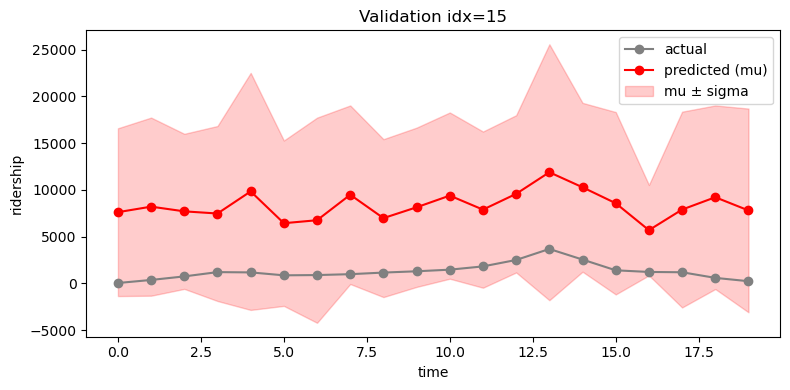

Fold 1 Validation:  33%|███▎      | 1/3 [00:01<00:03,  1.79s/it]

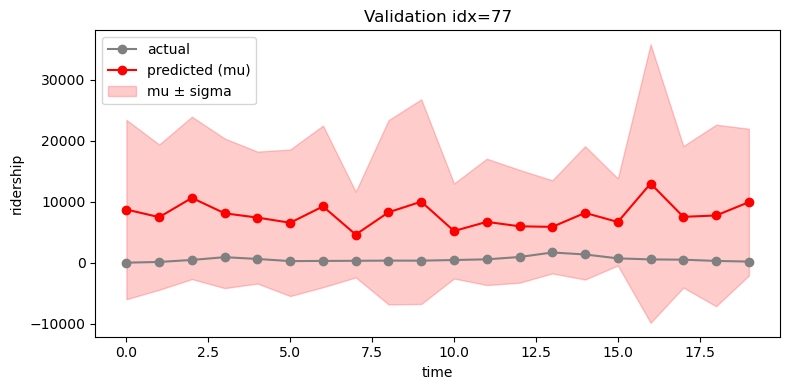

Fold 1 Validation:  67%|██████▋   | 2/3 [00:03<00:01,  1.50s/it]

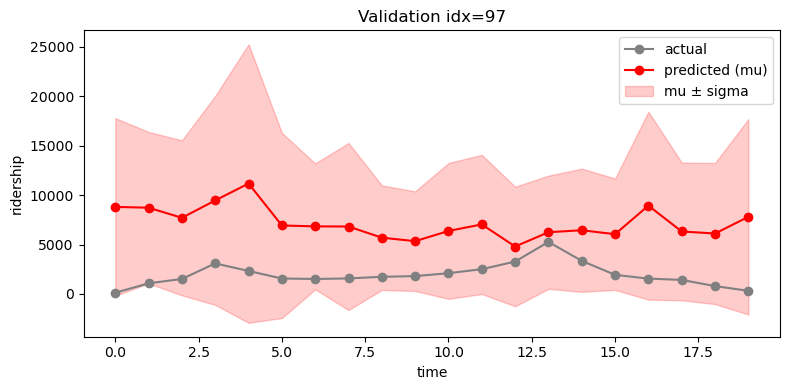

Fold 1 Validation: 100%|██████████| 3/3 [00:04<00:00,  1.45s/it]


392834.03955078125


Fold 2 Training:   8%|▊         | 7978/100000 [59:36<11:27:28,  2.23it/s]   


KeyboardInterrupt: 

In [ ]:
# K-fold validation version

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Set constants
num_folds = 20
num_samples = 50
num_iters = 10000
input_dim = 37
output_dim = 20
prior_scale = 10000.
learning_rate = 0.005

train_id = list(df[~df['name'].isin(['태릉입구', '상봉', '상도', '강남', '시청', '공덕'])].index)
test_id = list(df[df['name'].isin(['태릉입구', '상봉', '상도', '강남', '시청', '공덕'])].index)

train_data_x = df_x.iloc[train_id]
train_data_y = df_y['ridership'].iloc[train_id]

test_data_x = df_x.iloc[test_id]
test_data_y = df_y['ridership'].iloc[test_id]

# For 10-fold cross-validation on train_data (8:1 split)
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

fold_results = []
for fold, (train_idx, val_idx) in enumerate(kf.split(train_data_x)):

    train_input = train_data_x.iloc[train_idx]
    train_output = train_data_y.iloc[train_idx]

    val_input = train_data_x.iloc[val_idx]
    val_output = train_data_y.iloc[val_idx]

    # Create time-augmented ridership data
    x_stacks = []
    y_stacks = []
    for k, row in train_input.iterrows():
        # repeat df_x row for 20 time steps and stack with one-hot time vectors and ridership
        x_rep = np.tile(row.values.reshape(1, -1), (20, 1))
        time_onehots = np.eye(20)
        ridership_vals = np.array(train_output.loc[k]).reshape(-1, 1)
        temp_stack = np.hstack([time_onehots, x_rep])
        x_stacks.append(temp_stack)
        y_stacks.append(ridership_vals)

    train_x, train_y = np.vstack(x_stacks), np.vstack(y_stacks)
    
    x_train_tensor = torch.tensor(train_x, dtype=torch.float)
    y_train_tensor = torch.tensor(train_y, dtype=torch.float)
    
    x_train_tensor = x_train_tensor.to(device)
    y_train_tensor = y_train_tensor.to(device)
    
    # Reset model and optimizer
    model = BNN(input_dim=input_dim).to(device)
    guide = AutoMultivariateNormal(model, init_loc_fn=init_to_mean)
    svi = SVI(model, guide, optim.Adam({"lr": learning_rate}), loss=Trace_ELBO(vectorize_particles=True))
    pyro.clear_param_store()

    for i in tqdm(range(num_iters), desc=f"Fold {fold+1} Training"):
        svi.step(x_train_tensor, y_train_tensor.squeeze())

    fold_result_rows = []
    mse = 0

    
    for k, row in tqdm(val_input[:3].iterrows(), total=len(val_input[:3]), desc=f"Fold {fold+1} Validation"):
        # repeat df_x row for 20 time steps and stack with one-hot time vectors and ridership
        x_rep = np.tile(row.values.reshape(1, -1), (20, 1))
        time_onehots = np.eye(20)
        ridership_vals = np.array(val_output.loc[k]).reshape(-1, 1)
        temp_stack = np.hstack([time_onehots, x_rep])

        result_list = []

        inputs = temp_stack
        inputs_tensor = torch.tensor(inputs, dtype=torch.float)
            
        with torch.no_grad():
            preds = Predictive(model, guide=guide, num_samples=num_samples)(inputs_tensor)
            mus = preds['coefs'].mean(axis=0).numpy()
            sigmas = preds['coefs'].std(axis=0).numpy()

        ridership_flat = ridership_vals.flatten()

        # record results and update mse
        for t in range(len(mus)):
            mse += abs(float(mus[t]) - float(ridership_flat[t]))

        # plot actual (grey) vs predicted mu (red) with uncertainty band
        plt.figure(figsize=(8, 4))
        plt.plot(range(len(ridership_flat)), ridership_flat, color='grey', marker='o', label='actual')
        plt.plot(range(len(mus)), mus, color='red', marker='o', label='predicted (mu)')
        plt.fill_between(range(len(mus)), mus - sigmas, mus + sigmas, color='red', alpha=0.2, label='mu ± sigma')
        plt.xlabel('time')
        plt.ylabel('ridership')
        plt.title(f'Validation idx={k}')
        plt.legend()
        plt.tight_layout()
        plt.show()
    print(mse)



torch.Size([4400, 1])

Training:  20%|██        | 1004/5000 [00:37<02:24, 27.59it/s]

6740648802.502726


Training:  40%|████      | 2003/5000 [01:15<01:51, 26.88it/s]

777316267.534831


Training:  60%|██████    | 3006/5000 [02:01<01:11, 27.77it/s]

...

Training:  80%|████████  | 4003/5000 [02:46<00:43, 23.18it/s]

2144615680.5062666


Training: 100%|██████████| 5000/5000 [03:26<00:00, 24.26it/s]


1978698529.7003589


ValueError: x and y must have same first dimension, but have shapes (50,) and (5000,)

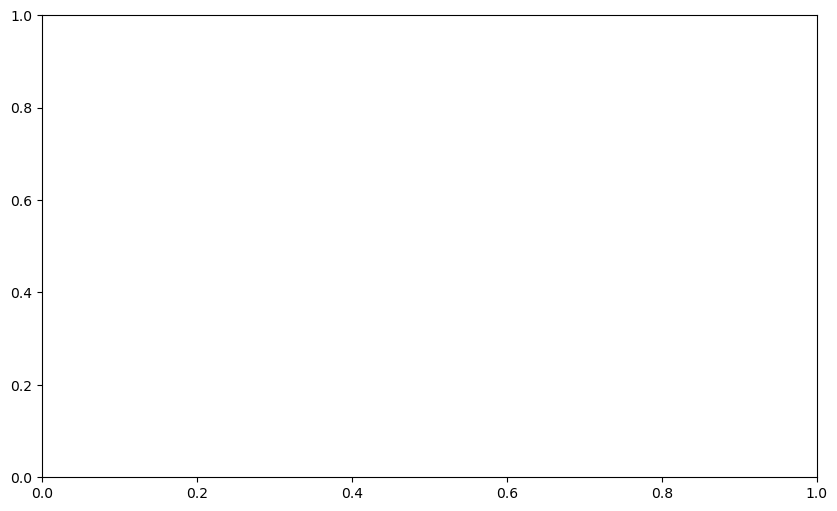

In [ ]:
# Selection and test version

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Set constants
num_samples = 50
num_iters = 5000
input_dim = 37
output_dim = 20
prior_scale = 10000.
learning_rate = 0.005

train_id = list(df[~df['name'].isin(['태릉입구', '상봉', '상도', '강남', '시청', '공덕'])].index)
test_id = list(df[df['name'].isin(['태릉입구', '상봉', '상도', '강남', '시청', '공덕'])].index)

train_data_x = df_x.iloc[train_id]
train_data_y = df_y['ridership'].iloc[train_id]

test_data_x = df_x.iloc[test_id]
test_data_y = df_y['ridership'].iloc[test_id]

train_input = train_data_x
train_output = train_data_y
val_input = test_data_x
val_output = test_data_y    

x_stacks, y_stacks = [], []

for k, row in train_input.iterrows():
    # repeat df_x row for 20 time steps and stack with one-hot time vectors and ridership
    x_rep = np.tile(row.values.reshape(1, -1), (20, 1))
    time_onehots = np.eye(20)
    ridership_vals = np.array(train_output.loc[k]).reshape(-1, 1)
    temp_stack = np.hstack([time_onehots, x_rep])
    x_stacks.append(temp_stack)
    y_stacks.append(ridership_vals)

train_x, train_y = np.vstack(x_stacks), np.vstack(y_stacks)

x_train_tensor = torch.tensor(train_x, dtype=torch.float)
y_train_tensor = torch.tensor(train_y, dtype=torch.float)

x_train_tensor = x_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)

# Reset model and optimizer
model = BNN(input_dim=input_dim).to(device)
guide = AutoMultivariateNormal(model, init_loc_fn=init_to_mean)
svi = SVI(model, guide, optim.Adam({"lr": learning_rate}), loss=Trace_ELBO(vectorize_particles=True))
pyro.clear_param_store()

losses = []

for i in tqdm(range(num_iters), desc=f"Training"):
    loss = svi.step(x_train_tensor, y_train_tensor.squeeze())
    losses.append(loss)
    if (i + 1) % 1000 == 0:
        print(loss)

result_rows = []
mse = 0

plt.figure(figsize=(10, 6))
plt.plot(range(0, len(losses)), losses, marker='o')
plt.xlabel('Epoch (x100)')
plt.ylabel('ELBO Loss')
plt.title('ELBO Loss During Training')
plt.grid(True)
plt.tight_layout()
plt.show()

for k, row in tqdm(val_input.iterrows(), total=len(val_input), desc=f" Validation"):
    # repeat df_x row for 20 time steps and stack with one-hot time vectors and ridership
    x_rep = np.tile(row.values.reshape(1, -1), (20, 1))
    time_onehots = np.eye(20)
    ridership_vals = np.array(val_output.loc[k]).reshape(-1, 1)
    temp_stack = np.hstack([time_onehots, x_rep])

    result_list = []

    inputs = temp_stack
    inputs_tensor = torch.tensor(inputs, dtype=torch.float)
        
    with torch.no_grad():
        preds = Predictive(model, guide=guide, num_samples=num_samples)(inputs_tensor)
        mus = preds['coefs'].mean(axis=0).numpy()
        sigmas = preds['coefs'].std(axis=0).numpy()

    ridership_flat = ridership_vals.flatten()

    # record results and update mse
    for t in range(len(mus)):
        mse += abs(float(mus[t]) - float(ridership_flat[t]))

    # plot actual (grey) vs predicted mu (red) with uncertainty band
    plt.figure(figsize=(8, 4))
    plt.plot(range(len(ridership_flat)), ridership_flat, color='grey', marker='o', label='actual')
    plt.plot(range(len(mus)), mus, color='red', marker='o', label='predicted (mu)')
    plt.fill_between(range(len(mus)), mus - sigmas, mus + sigmas, color='red', alpha=0.2, label='mu ± sigma')
    plt.xlabel('time')
    plt.ylabel('ridership')
    plt.title(f'Validation idx={k}')
    plt.legend()
    plt.tight_layout()
    plt.show()
print(mse)

Training:   3%|▎         | 1004/30000 [00:55<23:06, 20.91it/s]

22025.94193506241


Training:   7%|▋         | 2003/30000 [01:52<23:34, 19.79it/s]

19511.98539209366


Training:  10%|█         | 3003/30000 [02:58<32:40, 13.77it/s]  

...

14923.250528812408


Training:  97%|█████████▋| 29003/30000 [34:54<01:00, 16.49it/s]

14075.307901859283


Training: 100%|██████████| 30000/30000 [36:05<00:00, 13.86it/s]


13874.967936038971


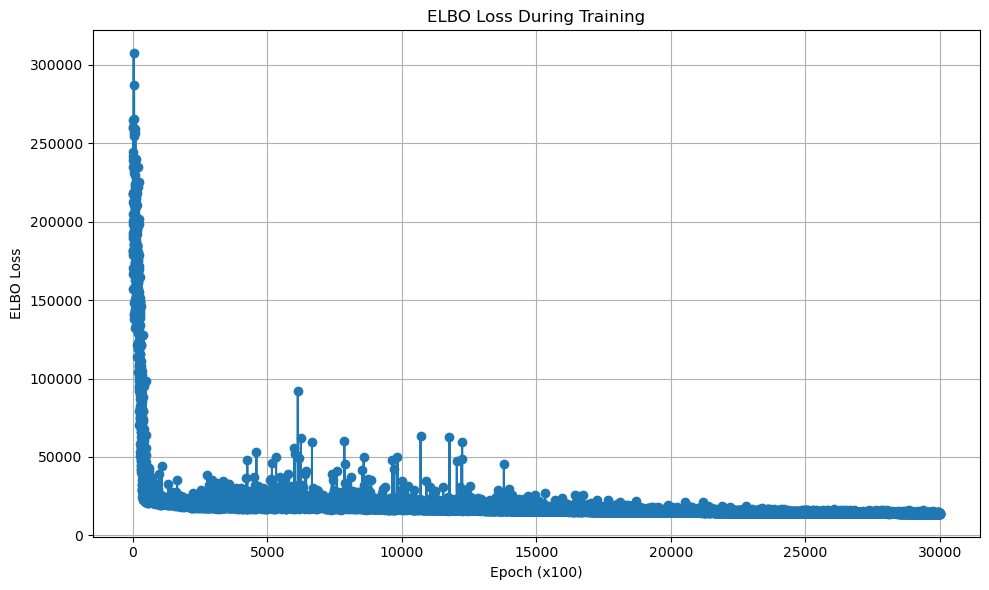

 Validation:   0%|          | 0/6 [00:00<?, ?it/s]

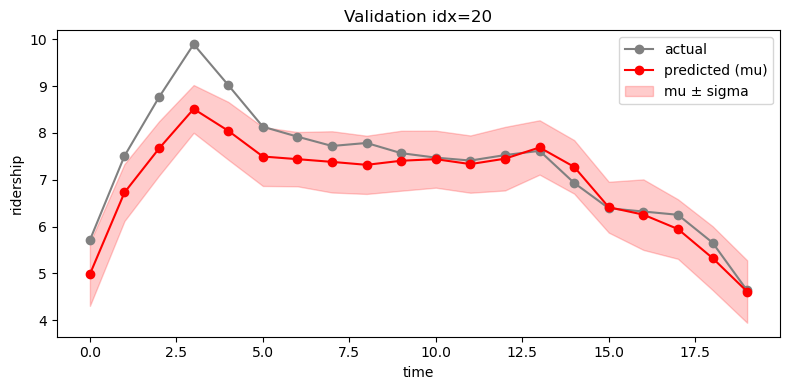

 Validation:  17%|█▋        | 1/6 [00:01<00:09,  1.97s/it]

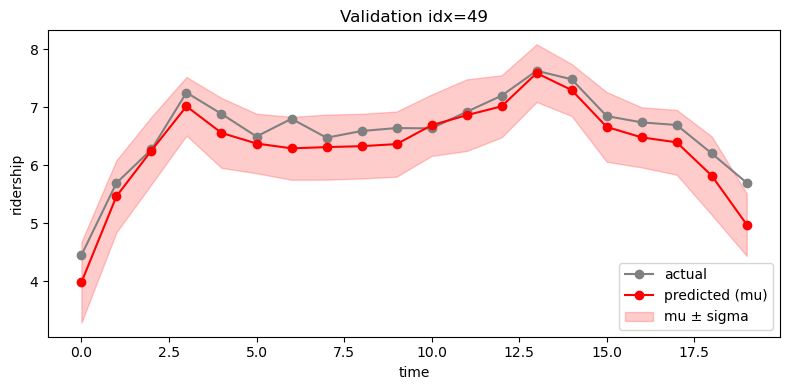

 Validation:  33%|███▎      | 2/6 [00:04<00:08,  2.06s/it]

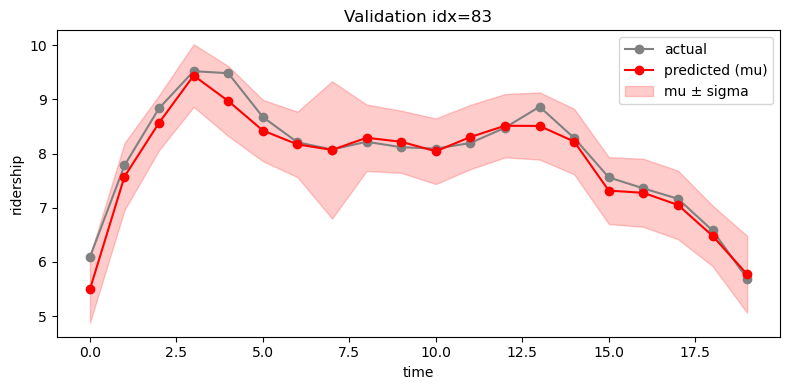

 Validation:  50%|█████     | 3/6 [00:05<00:05,  1.87s/it]

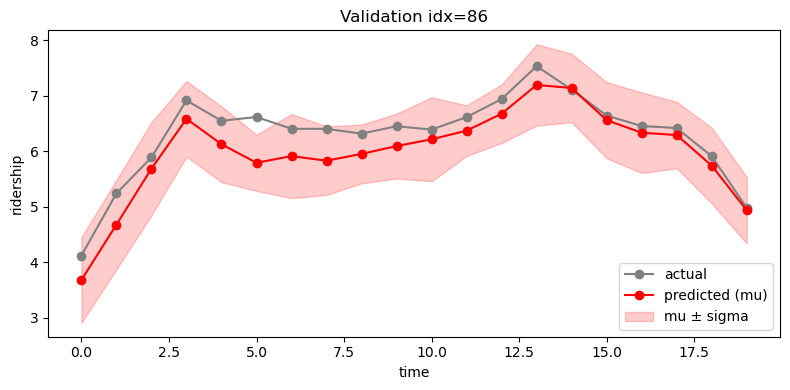

 Validation:  67%|██████▋   | 4/6 [00:07<00:03,  1.85s/it]

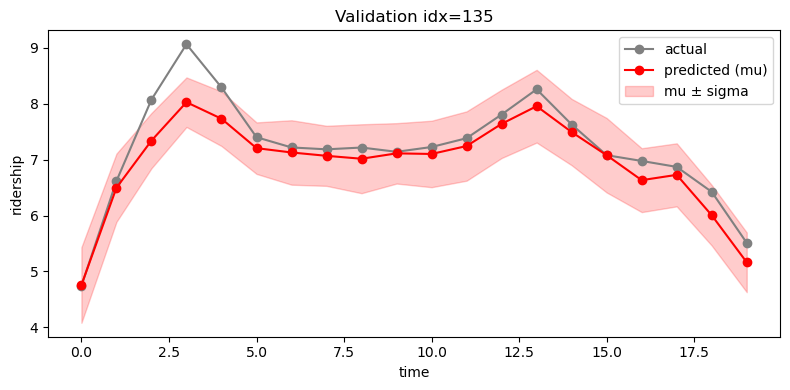

 Validation:  83%|████████▎ | 5/6 [00:09<00:01,  1.75s/it]

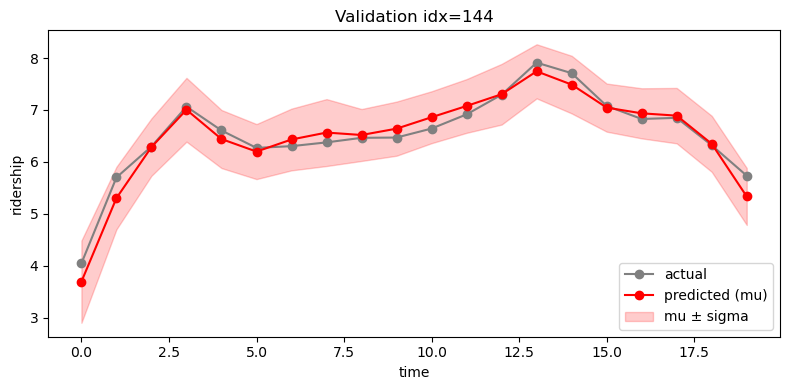

 Validation: 100%|██████████| 6/6 [00:10<00:00,  1.80s/it]

31.10882637980211


In [6]:
# Selection and test version + Log

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Set constants
num_samples = 50
num_iters = 30000
input_dim = 37
output_dim = 20
prior_scale = 10.
learning_rate = 0.0005

train_id = list(df[~df['name'].isin(['태릉입구', '상봉', '상도', '강남', '시청', '공덕'])].index)
test_id = list(df[df['name'].isin(['태릉입구', '상봉', '상도', '강남', '시청', '공덕'])].index)

train_data_x = df_x.iloc[train_id]
train_data_y = df_y['ridership'].iloc[train_id]

test_data_x = df_x.iloc[test_id]
test_data_y = df_y['ridership'].iloc[test_id]

train_input = train_data_x
train_output = train_data_y
val_input = test_data_x
val_output = test_data_y

x_stacks, y_stacks = [], []

for k, row in train_input.iterrows():
    # repeat df_x row for 20 time steps and stack with one-hot time vectors and ridership
    x_rep = np.tile(row.values.reshape(1, -1), (20, 1))
    time_onehots = np.eye(20)
    ridership_vals = np.array(train_output.loc[k]).reshape(-1, 1)
    ridership_vals = np.where(ridership_vals == 0, 1, ridership_vals) # avoid log(0)
    temp_stack = np.hstack([time_onehots, x_rep])
    x_stacks.append(temp_stack)
    y_stacks.append(ridership_vals)

train_x, train_y = np.vstack(x_stacks), np.vstack(y_stacks)

x_train_tensor = torch.tensor(train_x, dtype=torch.float)
y_train_tensor = torch.tensor(np.log(train_y), dtype=torch.float)

x_train_tensor = x_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)

# Reset model and optimizer
model = BNN(input_dim=input_dim).to(device)
guide = AutoMultivariateNormal(model, init_loc_fn=init_to_mean)
svi = SVI(model, guide, optim.Adam({"lr": learning_rate}), loss=Trace_ELBO(vectorize_particles=True))
pyro.clear_param_store()

losses = []

for i in tqdm(range(num_iters), desc=f"Training"):
    loss = svi.step(x_train_tensor, y_train_tensor.squeeze())
    if loss <= 10000000: losses.append(loss)
    if (i + 1) % 1000 == 0:
        print(loss)

result_rows = []
mse = 0

plt.figure(figsize=(10, 6))
plt.plot(range(0, len(losses)), losses, marker='o')
plt.xlabel('Epoch (x100)')
plt.ylabel('ELBO Loss')
plt.title('ELBO Loss During Training')
plt.grid(True)
plt.tight_layout()
plt.show()

for k, row in tqdm(val_input.iterrows(), total=len(val_input), desc=f" Validation"):
    # repeat df_x row for 20 time steps and stack with one-hot time vectors and ridership
    x_rep = np.tile(row.values.reshape(1, -1), (20, 1))
    time_onehots = np.eye(20)
    ridership_vals = np.array(val_output.loc[k]).reshape(-1, 1)
    ridership_vals = np.where(ridership_vals == 0, 1, ridership_vals) # avoid log(0)
    temp_stack = np.hstack([time_onehots, x_rep])

    result_list = []

    inputs = temp_stack
    inputs_tensor = torch.tensor(inputs, dtype=torch.float)
        
    with torch.no_grad():
        preds = Predictive(model, guide=guide, num_samples=num_samples)(inputs_tensor)
        mus = preds['coefs'].mean(axis=0).numpy()
        sigmas = preds['coefs'].std(axis=0).numpy()

    ridership_flat = np.log(ridership_vals).flatten()

    # record results and update mse
    for t in range(len(mus)):
        mse += abs(float(mus[t]) - float(ridership_flat[t]))

    # plot actual (grey) vs predicted mu (red) with uncertainty band
    plt.figure(figsize=(8, 4))
    plt.plot(range(len(ridership_flat)), ridership_flat, color='grey', marker='o', label='actual')
    plt.plot(range(len(mus)), mus, color='red', marker='o', label='predicted (mu)')
    plt.fill_between(range(len(mus)), mus - sigmas, mus + sigmas, color='red', alpha=0.2, label='mu ± sigma')
    plt.xlabel('time')
    plt.ylabel('ridership')
    plt.title(f'Validation idx={k}')
    plt.legend()
    plt.tight_layout()
    plt.show()
print(mse)

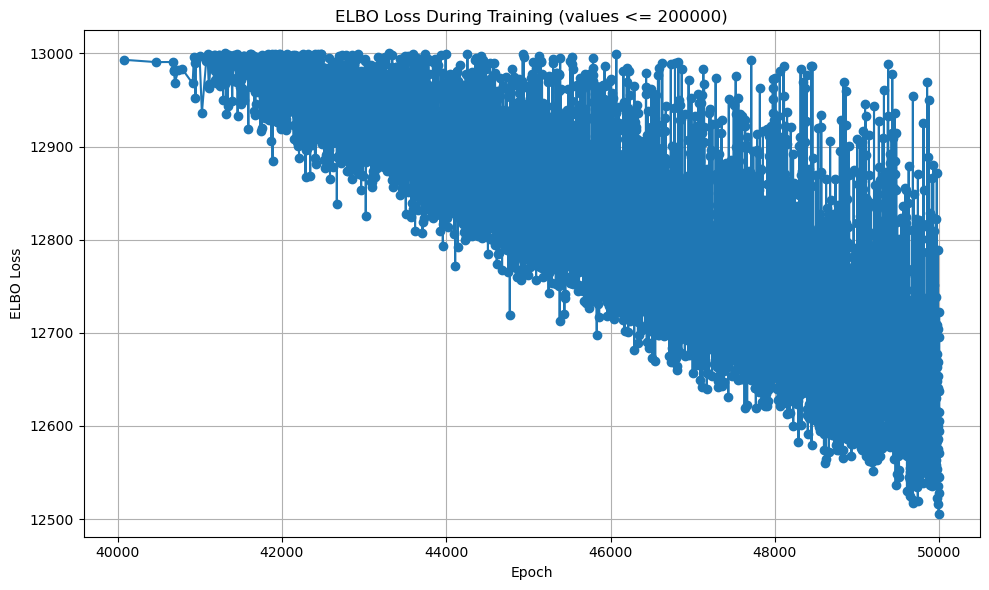

In [53]:
# plot losses excluding values > 200000
x = [i for i, l in enumerate(losses) if l <= 13000]
y = [l for l in losses if l <= 13000]

if not y:
    print("No loss values <= 200000 to plot.")
else:
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('ELBO Loss')
    plt.title('ELBO Loss During Training (values <= 200000)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [7]:
import pickle

# Save the trained model and guide

# Save model and guide to files
model_path = 'trained_model2.pkl'
guide_path = 'trained_guide2.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(model, f)

with open(guide_path, 'wb') as f:
    pickle.dump(guide, f)

print(f"Model saved to {model_path}")
print(f"Guide saved to {guide_path}")

Model saved to trained_model2.pkl
Guide saved to trained_guide2.pkl


In [13]:
df.loc[test_id]['name']

20       시청
49     태릉입구
83       강남
86       상도
135      공덕
144      상봉
Name: name, dtype: object

Model loaded from trained_model2.pkl
Guide loaded from trained_guide2.pkl


 Validation:   0%|          | 0/6 [00:00<?, ?it/s]

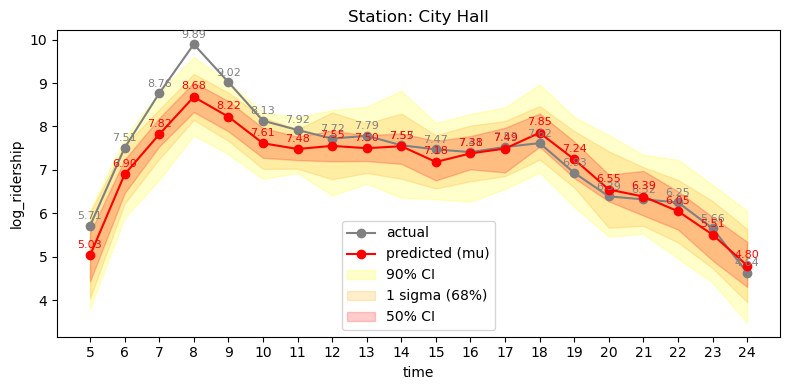

 Validation:  17%|█▋        | 1/6 [00:01<00:07,  1.60s/it]

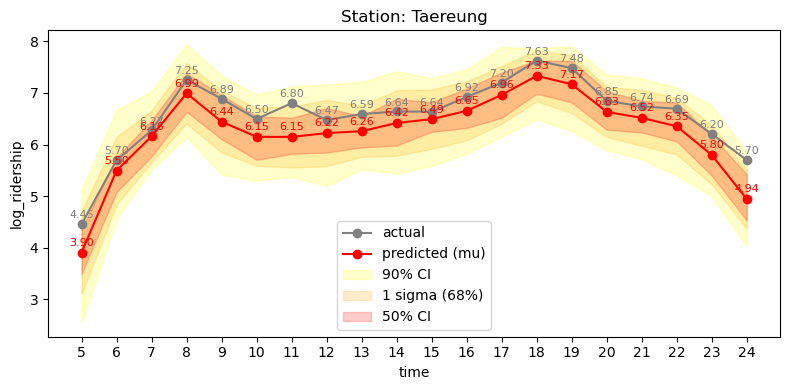

 Validation:  33%|███▎      | 2/6 [00:02<00:05,  1.35s/it]

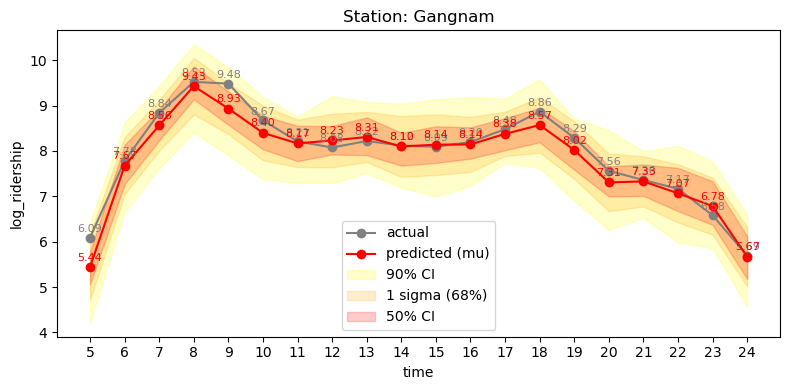

 Validation:  50%|█████     | 3/6 [00:03<00:03,  1.21s/it]

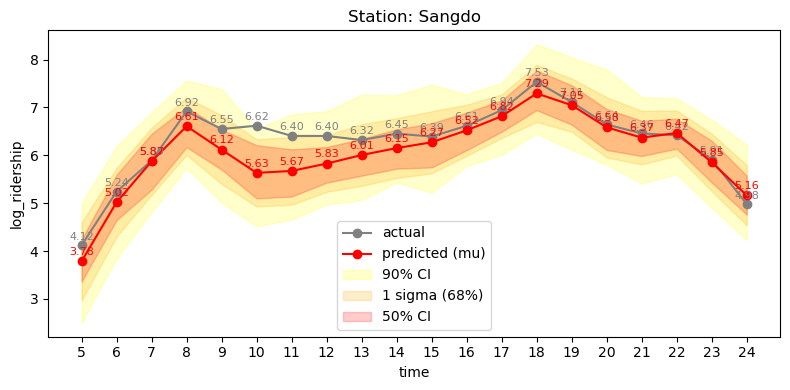

 Validation:  67%|██████▋   | 4/6 [00:04<00:02,  1.16s/it]

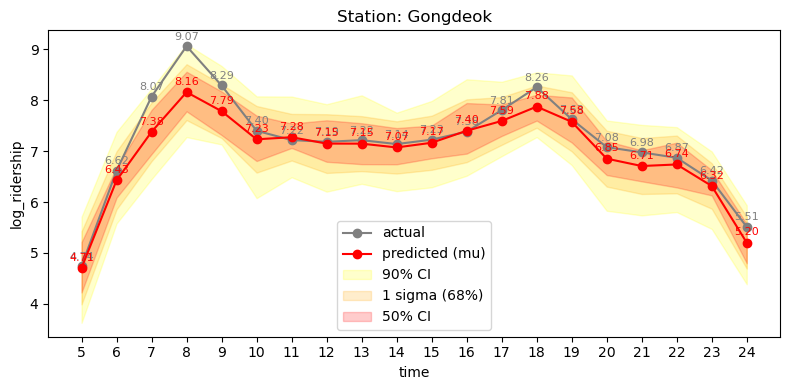

 Validation:  83%|████████▎ | 5/6 [00:05<00:01,  1.11s/it]

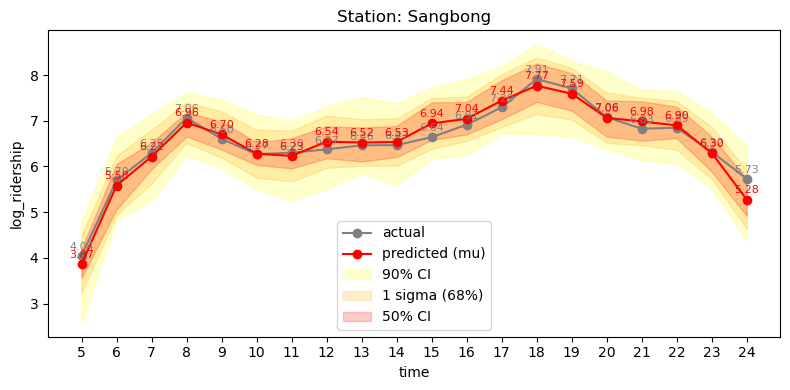

 Validation: 100%|██████████| 6/6 [00:07<00:00,  1.21s/it]

29.811497569624635


In [9]:
import pickle
# Load the trained model and guide
model_path = 'trained_model2.pkl'
guide_path = 'trained_guide2.pkl'

with open(model_path, 'rb') as f:
    model = pickle.load(f)

with open(guide_path, 'rb') as f:
    guide = pickle.load(f)

print(f"Model loaded from {model_path}")
print(f"Guide loaded from {guide_path}")

num_samples = 50
num_iters = 50000
input_dim = 37
output_dim = 20
prior_scale = 10.
learning_rate = 0.0005

train_id = list(df[~df['name'].isin(['태릉입구', '상봉', '상도', '강남', '시청', '공덕'])].index)
test_id = list(df[df['name'].isin(['태릉입구', '상봉', '상도', '강남', '시청', '공덕'])].index)

train_data_x = df_x.iloc[train_id]
train_data_y = df_y['ridership'].iloc[train_id]

test_data_x = df_x.iloc[test_id]
test_data_y = df_y['ridership'].iloc[test_id]

train_input = train_data_x
train_output = train_data_y
val_input = test_data_x
val_output = test_data_y

x_stacks, y_stacks = [], []

for k, row in train_input.iterrows():
    # repeat df_x row for 20 time steps and stack with one-hot time vectors and ridership
    x_rep = np.tile(row.values.reshape(1, -1), (20, 1))
    time_onehots = np.eye(20)
    ridership_vals = np.array(train_output.loc[k]).reshape(-1, 1)
    ridership_vals = np.where(ridership_vals == 0, 1, ridership_vals) # avoid log(0)
    temp_stack = np.hstack([time_onehots, x_rep])
    x_stacks.append(temp_stack)
    y_stacks.append(ridership_vals)

train_x, train_y = np.vstack(x_stacks), np.vstack(y_stacks)

x_train_tensor = torch.tensor(train_x, dtype=torch.float)
y_train_tensor = torch.tensor(np.log(train_y), dtype=torch.float)

x_train_tensor = x_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)


mse = 0

for k, row in tqdm(val_input.iterrows(), total=len(val_input), desc=f" Validation"):
    # repeat df_x row for 20 time steps and stack with one-hot time vectors and ridership
    x_rep = np.tile(row.values.reshape(1, -1), (20, 1))
    time_onehots = np.eye(20)
    ridership_vals = np.array(val_output.loc[k]).reshape(-1, 1)
    ridership_vals = np.where(ridership_vals == 0, 1, ridership_vals) # avoid log(0)
    temp_stack = np.hstack([time_onehots, x_rep])

    result_list = []

    inputs = temp_stack
    inputs_tensor = torch.tensor(inputs, dtype=torch.float)
        
    with torch.no_grad():
        preds = Predictive(model, guide=guide, num_samples=num_samples)(inputs_tensor)
        mus = preds['coefs'].mean(axis=0).numpy()
        sigmas = preds['coefs'].std(axis=0).numpy()

        # Calculate 50% confidence interval (25th to 75th percentile)
        mus_ci50_lower = np.percentile(preds['coefs'], 25, axis=0)
        mus_ci50_upper = np.percentile(preds['coefs'], 75, axis=0)
        
        # Calculate 90% confidence interval (5th to 95th percentile)
        mus_ci90_lower = np.percentile(preds['coefs'], 5, axis=0)
        mus_ci90_upper = np.percentile(preds['coefs'], 95, axis=0)

    ridership_flat = np.log(ridership_vals).flatten()

    # record results and update mse
    for t in range(len(mus)):
        mse += abs(float(mus[t]) - float(ridership_flat[t]))

    # station name
    st_name = df.loc[k]['en_name']

    # plot actual (grey) vs predicted mu (red) with uncertainty band
    plt.figure(figsize=(8, 4))
    plt.plot(range(len(ridership_flat)), ridership_flat, color='grey', marker='o', label='actual')
    plt.plot(range(len(mus)), mus, color='red', marker='o', label='predicted (mu)')
    plt.fill_between(range(len(mus)), mus_ci90_lower, mus_ci90_upper, color='yellow', alpha=0.2, label='90% CI')
    plt.fill_between(range(len(mus)), mus - sigmas, mus + sigmas, color='orange', alpha=0.2, label='1 sigma (68%)')
    plt.fill_between(range(len(mus)), mus_ci50_lower, mus_ci50_upper, color='red', alpha=0.2, label='50% CI')
    y_max = max(np.max(mus), np.max(ridership_flat))
    y_min = min(np.min(mus), np.min(ridership_flat))
    offset = (y_max - y_min) * 0.02 if y_max != y_min else 0.1
    plt.xticks(range(len(mus)), range(5, 25))

    for t in range(len(mus)):
        plt.text(t, float(ridership_flat[t]) + offset, f"{float(ridership_flat[t]):.2f}", color='grey', ha='center', va='bottom', fontsize=8)
        plt.text(t, float(mus[t]) + offset * 1.2, f"{float(mus[t]):.2f}", color='red', ha='center', va='bottom', fontsize=8)
    plt.xlabel('time')
    plt.ylabel('log_ridership')
    plt.title(f'Station: {st_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()
print(mse)

SyntaxError: unterminated string literal (detected at line 6) (2317184514.py, line 6)

In [49]:
ridership_flat

array([4.04305127, 5.69843487, 6.29452772, 7.06253433, 6.60394382,
       6.26833842, 6.30188611, 6.37434316, 6.46240524, 6.46769873,
       6.64092104, 6.91393614, 7.29342576, 7.91081069, 7.70796153,
       7.07716044, 6.82546004, 6.84736813, 6.31860769, 5.73269382])